In [13]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

In [14]:
# 1. Đọc dữ liệu từ file CSV
csv_path = "D:\\VSCode\\CS114\\final_114cardataset.csv"  # Thay bằng đường dẫn file CSV của bạn
data = pd.read_csv(csv_path)


In [16]:
# 2. Hàm Generator để xử lý ảnh theo batch
def data_generator(image_paths, labels, batch_size=32, target_size=(224, 224)):
    num_samples = len(image_paths)
    while True:
        for offset in range(0, num_samples, batch_size):
            batch_paths = image_paths[offset:offset + batch_size]
            batch_labels = labels[offset:offset + batch_size]

            batch_images = []
            for img_path in batch_paths:
                try:
                    img = load_img(img_path, target_size=target_size)  # Load và resize ảnh
                    img_array = img_to_array(img)
                    img_array = preprocess_input(img_array)  # Tiền xử lý cho MobileNetV2
                    batch_images.append(img_array)
                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")

            yield np.array(batch_images), np.array(batch_labels)

In [25]:
# 3. Xử lý dữ liệu
image_paths = data['ImageFullPath'].tolist()
labels = data['Label'].tolist()

# Chia dữ liệu thành train và test
X_train_paths, X_test_paths, y_train, y_test = train_test_split(image_paths, labels, test_size=0.2, random_state=42)
# Chia tập test thành validation và test riêng biệt
X_valid_paths, X_final_test_paths, y_valid, y_final_test = train_test_split(
    X_test_paths, y_test, test_size=0.5, random_state=42
)

# Tính toán class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

In [26]:
# 4. Tạo Data Generators
batch_size = 32
train_gen = data_generator(X_train_paths, y_train, batch_size=batch_size)
test_gen = data_generator(X_final_test_paths, y_final_test, batch_size=batch_size)
val_gen = data_generator(X_valid_paths, y_valid, batch_size=batch_size)

# Số lượng ảnh trong train và test
total_train = len(X_train_paths)
total_test = len(X_test_paths)
total_valid = len(X_valid_paths)

In [27]:
# 5. Tải MobileNetV2 pre-trained và xây dựng mô hình
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tune: Bỏ đóng băng một số tầng cuối
base_model.trainable = True
for layer in base_model.layers[:-50]:  # Đóng băng tất cả ngoại trừ 50 tầng cuối
    layer.trainable = False

# Thêm các tầng Fully Connected
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),  # Tính trung bình toàn cục trên đặc trưng
    Dense(256, activation='relu'),  # Tầng Fully Connected 1
    Dropout(0.4),                   # Dropout để tránh overfitting
    Dense(128, activation='relu'),  # Tầng Fully Connected 2
    Dropout(0.3),
    Dense(len(np.unique(labels)), activation='softmax')  # Lớp đầu ra với số lớp = số nhãn
])

# Compile mô hình với learning rate thấp để fine-tune
model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [28]:
# 6. Huấn luyện mô hình
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(
    train_gen,
    steps_per_epoch=total_train // batch_size,
    validation_data=val_gen,
    validation_steps=total_valid // batch_size,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
  2/795 [..............................] - ETA: 8:38 - loss: 2.7052 - accuracy: 0.1406   

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


795/795 [==============================] - 998s 1s/step - loss: 2.2800 - accuracy: 0.1623 - val_loss: 2.0264 - val_accuracy: 0.2762
Epoch 2/20
795/795 [==============================] - 1089s 1s/step - loss: 2.0667 - accuracy: 0.2511 - val_loss: 1.8962 - val_accuracy: 0.3259
Epoch 3/20
795/795 [==============================] - 865s 1s/step - loss: 1.9484 - accuracy: 0.3099 - val_loss: 1.7963 - val_accuracy: 0.3723
Epoch 4/20
795/795 [==============================] - 845s 1s/step - loss: 1.8338 - accuracy: 0.3590 - val_loss: 1.6976 - val_accuracy: 0.4206
Epoch 5/20
795/795 [==============================] - 720s 906ms/step - loss: 1.7130 - accuracy: 0.4057 - val_loss: 1.6102 - val_accuracy: 0.4444
Epoch 6/20
795/795 [==============================] - 674s 849ms/step - loss: 1.5907 - accuracy: 0.4496 - val_loss: 1.5219 - val_accuracy: 0.4727
Epoch 7/20
795/795 [==============================] - 674s 848ms/step - loss: 1.4843 - accuracy: 0.4850 - val_loss: 1.4509 - val_accuracy: 0.5006


In [29]:
y_pred = []
y_true = []
for _ in range(len(X_final_test_paths) // batch_size):
    batch_images, batch_labels = next(test_gen)
    batch_preds = model.predict(batch_images)
    y_pred.extend(np.argmax(batch_preds, axis=1))
    y_true.extend(batch_labels)


1/1 [==============================] - 0s 263ms/step


In [30]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred, digits=4))

Accuracy: 0.617739898989899
Classification Report:
               precision    recall  f1-score   support

           0     0.6096    0.5475    0.5769       442
           1     0.6058    0.4899    0.5417       298
           2     0.5452    0.6098    0.5757       287
           3     0.4916    0.5465    0.5176       269
           4     0.6254    0.6189    0.6221       286
           5     0.5507    0.6189    0.5828       307
           6     0.8180    0.7023    0.7558       608
           7     0.5725    0.6494    0.6085       462
           8     0.6483    0.7321    0.6876       209

    accuracy                         0.6177      3168
   macro avg     0.6075    0.6128    0.6076      3168
weighted avg     0.6263    0.6177    0.6193      3168



1/1 [==============================] - 1s 890ms/step
Vector đặc trưng (shape): (1, 7, 7, 1280)
Vector đặc trưng: [[[[0.9723544  0.         0.         ... 0.         0.
    0.        ]
   [2.346694   0.         0.         ... 0.         0.
    0.6229205 ]
   [2.5977025  0.         0.         ... 0.         0.
    0.        ]
   ...
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]]

  [[0.84675264 0.         0.         ... 1.1637597  0.
    2.3919816 ]
   [0.7774043  0.         0.         ... 4.775865   0.
    0.        ]
   [0.         0.         0.         ... 2.2828255  0.
    0.        ]
   ...
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]]

  [[0.         0.

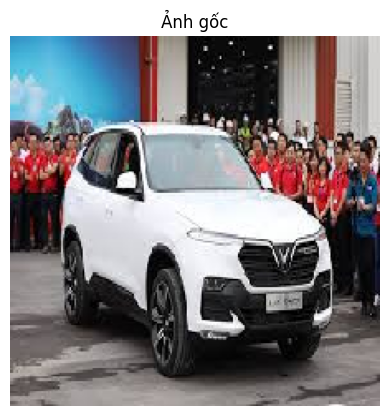

In [31]:
import matplotlib.pyplot as plt

# 8. Trích xuất đặc trưng từ một ảnh bất kỳ
def extract_features_from_image(image_path):
    # Load và xử lý ảnh
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)  # Thêm chiều batch

    # Trích xuất đặc trưng
    features = base_model.predict(img_array)
    print("Vector đặc trưng (shape):", features.shape)
    print("Vector đặc trưng:", features)

    # Hiển thị ảnh gốc
    plt.imshow(img)
    plt.title("Ảnh gốc")
    plt.axis('off')
    plt.show()

# Ví dụ: Trích xuất đặc trưng từ một ảnh bất kỳ
image_path = "D:\\Dataset\\FinalData_CS114\\VinFast\\21520930-21522924.VinFast.28-.png"  # Thay đường dẫn ảnh tại đây
extract_features_from_image(image_path)